# Week 3 Using a pretrrained modelfor CIFAR-10 image classification

## Task Description

For this week's assignment, I will be working with CIFAR-10 dataset, which consists of 60,000 32x32 color images in 10 different classes. The task is to use a pre-trained ConvNet model along with a small fully connected network to classify the images into their respective classes. The pre-trained model will be used as a feature extractor, and the fully connected network will be trained on top of the extracted features to perform the classification task.

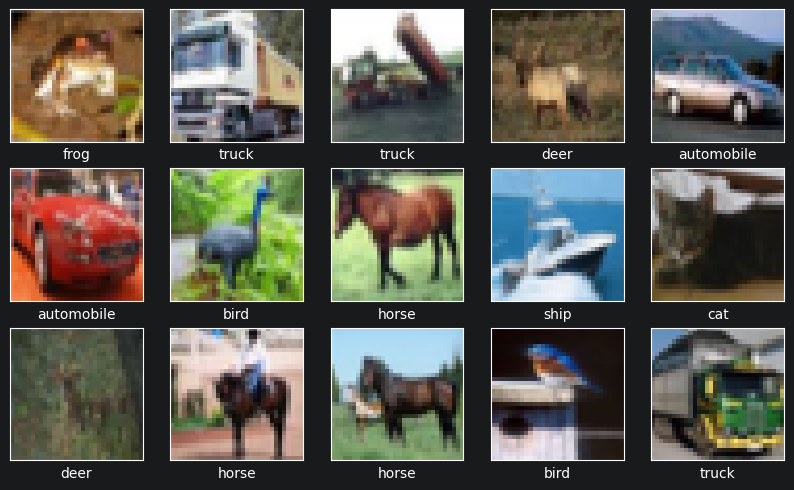

In [49]:
# Importing necessary libraries
import keras
from keras import layers, models
from keras.datasets import cifar10
from keras.applications.vgg16 import preprocess_input
from keras.applications import VGG16
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Display a few sample images with their correct labels
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10, 10))
for i in range(15):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

## Data Preprocessing

For data preprocessing, I will first split the training data into a smaller training set and a validation set. This allows monitoring the model's performance on unseen data during training. I will also scale the pixel values of the images correctly 1 by using the `keras.application.vgg16.preprocess_input` function, which is commonly used for pre-trained models. This scaling helps the model to converge faster during training.

In [50]:
# Split the training data into a smaller training set and a validation set (80-20 split)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

# Raw copy is saved for showing the images in later predictions when evaluating
x_test_raw = x_test.copy()

# Scaling the pixel values of the images to be between 0 and 1
x_train = x_train.astype('float32')
x_val = x_val.astype('float32')
x_test = x_test.astype('float32')

x_train = preprocess_input(x_train)
x_val = preprocess_input(x_val)
x_test = preprocess_input(x_test)

# Print the shapes of the datasets and few sample images with correct labels
print("Training set shape:", x_train.shape, y_train.shape)
print("Validation set shape:", x_val.shape, y_val.shape)
print("Test set shape:", x_test.shape, y_test.shape)

Training set shape: (40000, 32, 32, 3) (40000, 1)
Validation set shape: (10000, 32, 32, 3) (10000, 1)
Test set shape: (10000, 32, 32, 3) (10000, 1)


## Loading the Pre-trained Model and Feature Extraction

### Loading the Pre-trained Model

I will load the VGG16 model, which is a popular pre-trained ConvNet model, without the top fully connected layers. This allows me to use the convolutional base of the VGG16 model as a feature extractor for the CIFAR-10 images. I will set `include_top=False` to exclude the fully connected layers and `input_shape=(32, 32, 3)` to specify the input shape of the CIFAR-10 images. I will set freeze the convolutional base by setting `trainable=False`, which means that the weights of the VGG16 model will not be updated during training.

In [51]:
# Load the VGG16 model without the top fully connected layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
# Freeze the convolutional base
base_model.trainable = False

### Feature Extraction

Feature extraction involves passing the input images through the frozen VGG16 base to obtain the feature maps. These feature maps will then be used as input to the fully connected network for classification. The `extract_features` function takes in the data and uses the `predict` method of the base model to extract features in batches, which is more efficient for large datasets.

In [52]:
# Extract features using the frozen VGG16 base
def extract_features(data, batch_size=32):
    features = base_model.predict(data, batch_size=batch_size, verbose=0)
    return features

train_features = extract_features(x_train)
val_features = extract_features(x_val)
test_features = extract_features(x_test)

print("Train features shape:", train_features.shape)
print("Val features shape:", val_features.shape)
print("Test features shape:", test_features.shape)

Train features shape: (40000, 1, 1, 512)
Val features shape: (10000, 1, 1, 512)
Test features shape: (10000, 1, 1, 512)


## Building the Fully Connected Network

My goal was to aim for the highest possible accuracy on the validation set by experimenting with different architectures for the fully connected network. All of the architectures will start with a Global Average Pooling layer to reduce the spatial dimensions of the feature maps, followed by one or more Dense layers with ReLU activation and Dropout layers for regularization.

The first model I tried had one Dense layer with 256 units and a Dropout of 0.5, which achieved a validation accuracy of around 64.73%.

For the second model, I added an extra Dense layer with 128 units and a Dropout of 0.3, which improved the validation accuracy to around 67.50%.

Finally, I wanted to see if adding more layers would further improve the performance, so I added another Dense layer with 256 units and a Dropout of 0.5 and another Dense layer with 64 units and a Dropout of 0.2, but this did not improve the validation accuracy and actually resulted in a slightly lower accuracy of around 66.64%. This was a sign to me, that adding too many layers leads to overfitting on the training data, which can negatively impact the model's performance on unseen data.

In [54]:
# Build the fully connected classifier
inputs = layers.Input(shape=(1, 1, 512))
x = layers.GlobalAveragePooling2D()(inputs)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

classifier = models.Model(inputs, outputs)
classifier.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,514 (646.54 KB)

 Trainable params: 165,514 (646.54 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# Compile the model
classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Training the Model

For the training process I used callbacks to implement early stopping, which helps to prevent overfitting by monitoring the validation loss and stopping the training process if the validation loss does not improve for a certain number of epochs (patience). In this case, I set the patience to 10 epochs, which means that if the validation loss does not improve for 10 consecutive epochs, the training will stop and the best weights will be restored.

In [56]:
# Train the model
history = classifier.fit(
    train_features, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(val_features, y_val),
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ],
)

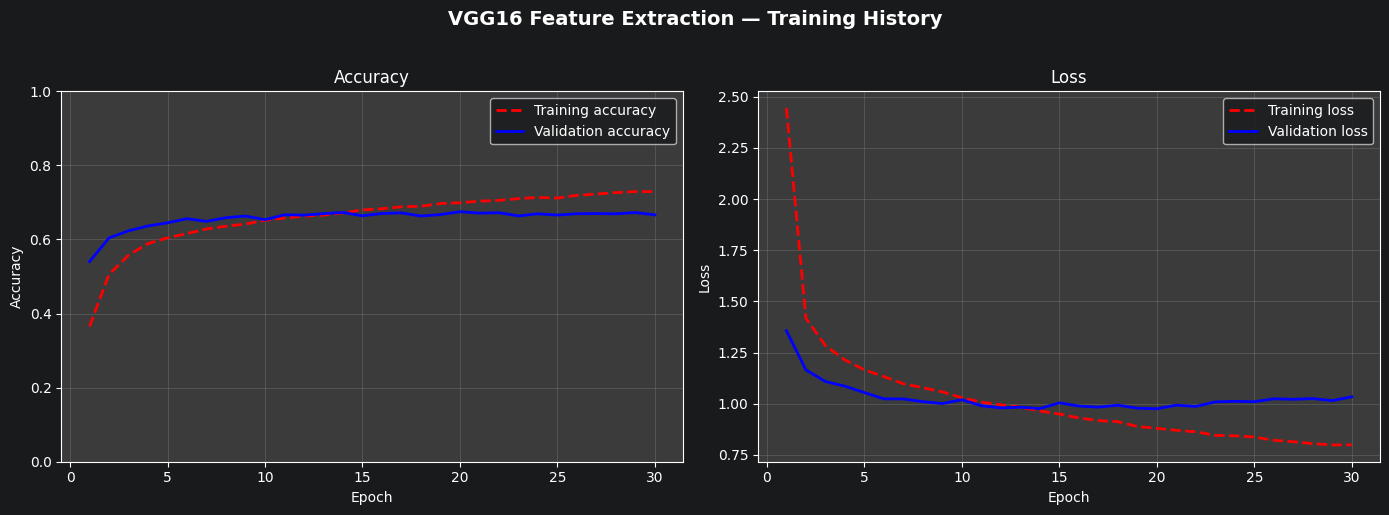

In [57]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.set_facecolor('#3b3b3b')         # <-- add this
ax2.set_facecolor('#3b3b3b')         # <-- add this
fig.suptitle('VGG16 Feature Extraction — Training History', fontsize=14, fontweight='bold', y=1.02)

# Accuracy plot
ax1.plot(epochs, acc, 'r--', linewidth=2, label='Training accuracy')
ax1.plot(epochs, val_acc, 'b', linewidth=2, label='Validation accuracy')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# Loss plot
ax2.plot(epochs, loss, 'r--', linewidth=2, label='Training loss')
ax2.plot(epochs, val_loss, 'b', linewidth=2, label='Validation loss')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluating the Model

From the plotted data above, we can see that the training accuracy and validation accuracy both improve over time, but the early stopping mechanism has stopped the training process at around 30 epochs, which indicates that the model has likely reached its optimal performance on the validation set.

In [61]:
# Evaluate the model on the validation set
val_loss, val_acc = classifier.evaluate(val_features, y_val, verbose=0)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")

Validation loss: 0.9754
Validation accuracy: 0.6750


In [58]:
# Evaluate the model on the test set
test_loss, test_acc = classifier.evaluate(test_features, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 1.0035
Test accuracy: 0.6712


The validation accuracy of around 67.50% and test accuracy of around 67.12% are not too far off from each other, which suggests that the model is generalizing well to unseen data. However, there is still room for improvement, and further experimentation with different architectures, hyperparameters, or even using a different pre-trained model could potentially yield better results.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step


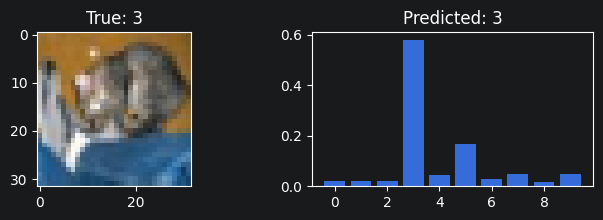

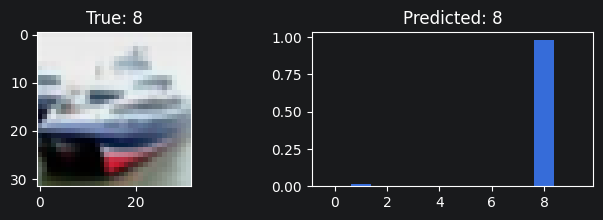

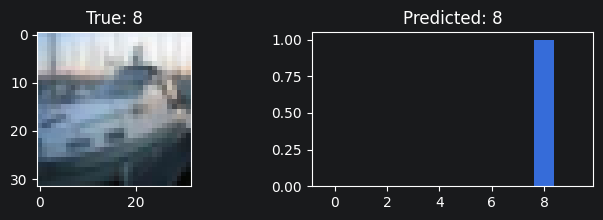

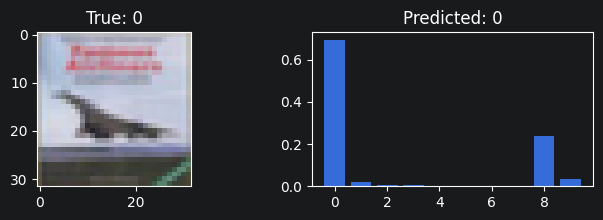

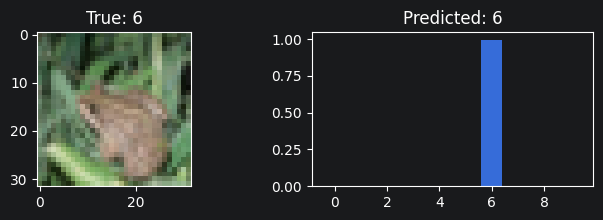

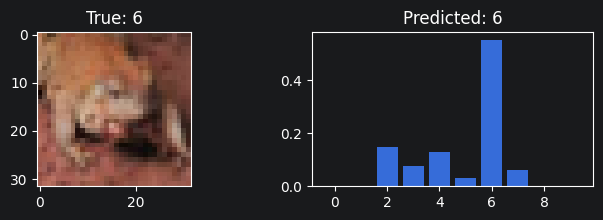

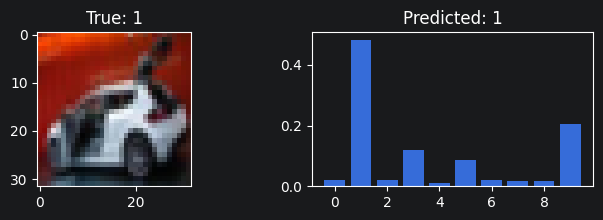

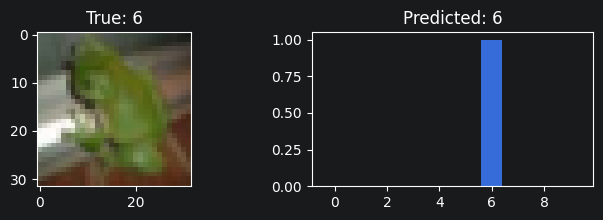

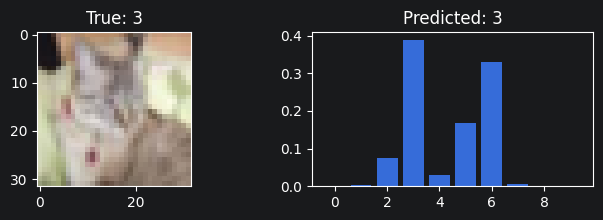

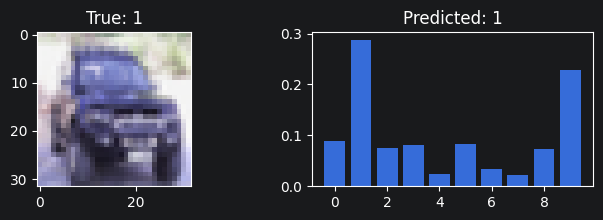

In [60]:
predictions = classifier.predict(test_features)
start = 0

for k in range(10):
    plt.figure(figsize=(8, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(x_test_raw[start+k])
    plt.title(f"True: {y_test[start+k][0]}")
    plt.subplot(1, 2, 2)
    plt.bar(range(10), predictions[start+k])
    plt.title(f"Predicted: {np.argmax(predictions[start+k])}")
    plt.show()

From the sample predictions above we can see that the model is quite certain on a few specific images, but on others it is quite literally just guessing.